# Alpha and Beta from Market Data

This notebook estimates market sensitivities from return data. In options, **Greeks** usually means delta, gamma, theta, vega, and rho. In equity research and portfolio work, the closest market-data sensitivities are measures such as alpha, beta, correlation, tracking error, and residual volatility.

This notebook does not calculate option Greeks such as delta or gamma. Those require option prices, strike prices, expiration dates, interest rates, dividends, and implied volatility. They belong in a separate options-pricing notebook.

Abbreviations used in this notebook:

- **CAPM**: Capital Asset Pricing Model, a formula for estimating expected equity return from market risk.
- **OLS**: Ordinary Least Squares, the standard linear regression method.
- **CHF**: Swiss franc, the currency used in examples where needed.

## 1. Intuition

A stock's return can be split into two broad parts:

- **Market-related movement**: the part explained by broad market returns.
- **Stock-specific movement**: the part left over after market movement is accounted for.

**Beta** measures how strongly the stock tends to move with the market. **Alpha** measures the average return left unexplained by the market model. In a regression, alpha is the intercept: the return the model estimates when market excess return is zero. Alpha sounds attractive, but it is only meaningful if it is estimated carefully and survives out-of-sample testing.

This notebook belongs after OHLCV and return calculations, but before WACC and valuation. Market data creates the return series; regression turns those returns into beta; valuation later uses beta as a CAPM input.

## 2. Mathematics

**Simple return:**

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Where:

- $R_t$ = simple return in period $t$
- $P_t$ = price in period $t$
- $P_{t-1}$ = price in the previous period
- $t$ = time period index

**Excess return:**

$$
R^e_t = R_t - R_{f,t}
$$

Where:

- $R^e_t$ = excess return in period $t$
- $R_t$ = asset return in period $t$
- $R_{f,t}$ = risk-free return in period $t$

**Beta from covariance:**

$$
\beta_i = \frac{Cov(R_i, R_m)}{Var(R_m)}
$$

Where:

- $\beta_i$ = beta of asset $i$
- $R_i$ = return of asset $i$
- $R_m$ = market or benchmark return
- $Cov(R_i, R_m)$ = covariance between asset and market returns
- $Var(R_m)$ = variance of market returns

**CAPM regression:**

$$
R_i - R_f = \alpha_i + \beta_i(R_m - R_f) + \epsilon_i
$$

Where:

- $R_i$ = return of asset $i$
- $R_f$ = risk-free return
- $\alpha_i$ = alpha, the intercept or average unexplained excess return
- $\beta_i$ = beta, sensitivity to market excess return
- $R_m$ = market return
- $\epsilon_i$ = residual return not explained by the market model

**Approximate annualized alpha:**

$$
\alpha_{annual} \approx \alpha_{daily} \times 252
$$

Where:

- $\alpha_{annual}$ = approximate annualized alpha
- $\alpha_{daily}$ = daily alpha estimated from the regression
- $252$ = approximate number of trading days in one year

## 3. Implementation

We will create synthetic daily market data for one stock and one benchmark. The synthetic stock is designed to behave like a defensive company with beta below 1.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.4f}".format
np.random.seed(44)

trading_days = pd.bdate_range("2024-01-02", periods=504)
risk_free_daily = 0.015 / 252

market_return = np.random.normal(loc=0.00035, scale=0.0100, size=len(trading_days))
true_beta = 0.72
true_alpha_daily = 0.00004
idiosyncratic_noise = np.random.normal(loc=0.0, scale=0.0065, size=len(trading_days))

stock_return = risk_free_daily + true_alpha_daily + true_beta * (market_return - risk_free_daily) + idiosyncratic_noise

data = pd.DataFrame({
    "date": trading_days,
    "risk_free": risk_free_daily,
    "market_return": market_return,
    "stock_return": stock_return,
})

data["market_price"] = 100 * (1 + data["market_return"]).cumprod()
data["stock_price"] = 100 * (1 + data["stock_return"]).cumprod()
data["market_excess_return"] = data["market_return"] - data["risk_free"]
data["stock_excess_return"] = data["stock_return"] - data["risk_free"]

data.head().style.format({
    "risk_free": "{:.4%}",
    "market_return": "{:.2%}",
    "stock_return": "{:.2%}",
    "market_price": "{:,.2f}",
    "stock_price": "{:,.2f}",
    "market_excess_return": "{:.2%}",
    "stock_excess_return": "{:.2%}",
})

,date,risk_free,market_return,stock_return,market_price,stock_price,market_excess_return,stock_excess_return
0,2024-01-02 00:00:00,0.0060%,-0.72%,-0.43%,99.28,99.57,-0.72%,-0.44%
1,2024-01-03 00:00:00,0.0060%,1.35%,0.94%,100.63,100.50,1.35%,0.93%
2,2024-01-04 00:00:00,0.0060%,1.28%,-1.03%,101.92,99.46,1.28%,-1.04%
3,2024-01-05 00:00:00,0.0060%,-1.57%,-1.37%,100.32,98.11,-1.58%,-1.37%
4,2024-01-08 00:00:00,0.0060%,-1.43%,0.19%,98.88,98.29,-1.44%,0.18%


In [8]:
def estimate_alpha_beta(asset_excess_return, market_excess_return):
    x = market_excess_return.to_numpy()
    y = asset_excess_return.to_numpy()
    x_matrix = np.column_stack([np.ones(len(x)), x])
    alpha, beta = np.linalg.lstsq(x_matrix, y, rcond=None)[0]
    fitted = alpha + beta * x
    residuals = y - fitted
    r_squared = 1 - (residuals @ residuals) / ((y - y.mean()) @ (y - y.mean()))
    return alpha, beta, fitted, residuals, r_squared

alpha_daily, beta, fitted, residuals, r_squared = estimate_alpha_beta(
    data["stock_excess_return"],
    data["market_excess_return"],
)

covariance_beta = data[["stock_excess_return", "market_excess_return"]].cov().iloc[0, 1] / data["market_excess_return"].var()
correlation = data["stock_excess_return"].corr(data["market_excess_return"])
tracking_error = (data["stock_return"] - data["market_return"]).std() * np.sqrt(252)
residual_volatility = pd.Series(residuals).std() * np.sqrt(252)

summary = pd.Series({
    "estimated_daily_alpha": alpha_daily,
    "estimated_annualized_alpha": alpha_daily * 252,
    "estimated_beta_regression": beta,
    "estimated_beta_covariance": covariance_beta,
    "correlation_with_market": correlation,
    "r_squared": r_squared,
    "tracking_error": tracking_error,
    "residual_volatility": residual_volatility,
})

summary.to_frame("value").style.format({"value": "{:.2%}"}, subset=pd.IndexSlice[[
    "estimated_daily_alpha",
    "estimated_annualized_alpha",
    "correlation_with_market",
    "r_squared",
    "tracking_error",
    "residual_volatility",
], :]).format({"value": "{:.2f}"}, subset=pd.IndexSlice[[
    "estimated_beta_regression",
    "estimated_beta_covariance",
], :])

,value
estimated_daily_alpha,-0.03%
estimated_annualized_alpha,-6.67%
estimated_beta_regression,0.71
estimated_beta_covariance,0.71
correlation_with_market,73.90%
r_squared,54.61%
tracking_error,11.29%
residual_volatility,10.33%


Beta from regression and beta from covariance match because they are two views of the same single-factor relationship. Regression also gives alpha, fitted returns, residuals, and $R^2$.

In [9]:
window = 63
rolling_beta = data["stock_excess_return"].rolling(window).cov(data["market_excess_return"]) / data["market_excess_return"].rolling(window).var()
data["rolling_beta_63d"] = rolling_beta
data["fitted_excess_return"] = fitted
data["residual_return"] = residuals

rolling_summary = data[["date", "rolling_beta_63d"]].dropna().tail()
rolling_summary.style.format({"rolling_beta_63d": "{:.2f}"})

,date,rolling_beta_63d
499,2025-12-01 00:00:00,0.70
500,2025-12-02 00:00:00,0.70
501,2025-12-03 00:00:00,0.69
502,2025-12-04 00:00:00,0.70
503,2025-12-05 00:00:00,0.71


## 4. Visualization

The scatter plot shows the fitted market relationship. The rolling beta chart shows why beta should be treated as an estimate, not a permanent property of the company.

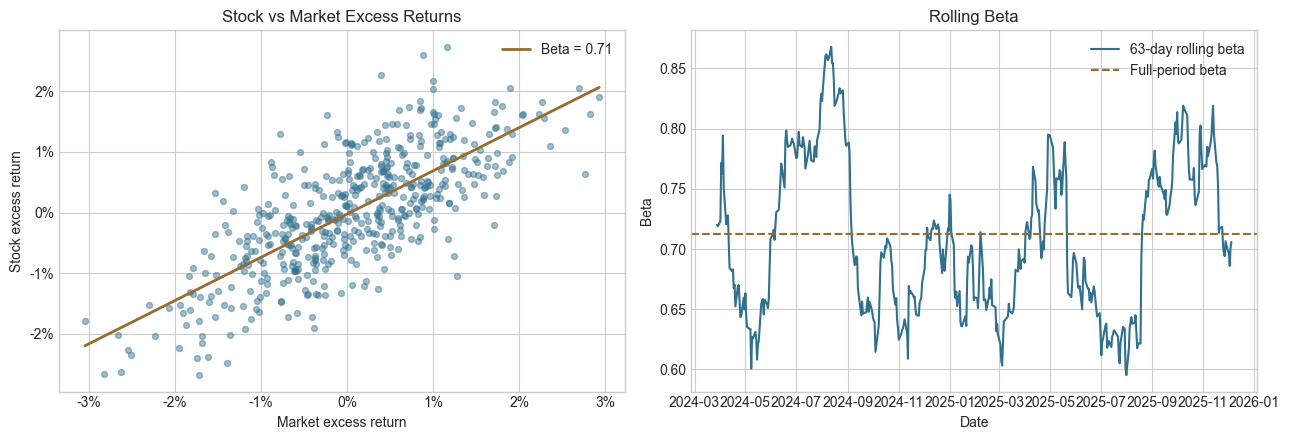

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(data["market_excess_return"], data["stock_excess_return"], color="#2f6f8f", alpha=0.45, s=18)
x_line = np.linspace(data["market_excess_return"].min(), data["market_excess_return"].max(), 100)
y_line = alpha_daily + beta * x_line
axes[0].plot(x_line, y_line, color="#9a6b2f", linewidth=2, label=f"Beta = {beta:.2f}")
axes[0].set_title("Stock vs Market Excess Returns")
axes[0].set_xlabel("Market excess return")
axes[0].set_ylabel("Stock excess return")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
axes[0].legend()

axes[1].plot(data["date"], data["rolling_beta_63d"], color="#2f6f8f", label="63-day rolling beta")
axes[1].axhline(beta, color="#9a6b2f", linestyle="--", label="Full-period beta")
axes[1].set_title("Rolling Beta")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Beta")
axes[1].legend()

plt.tight_layout()
plt.show()

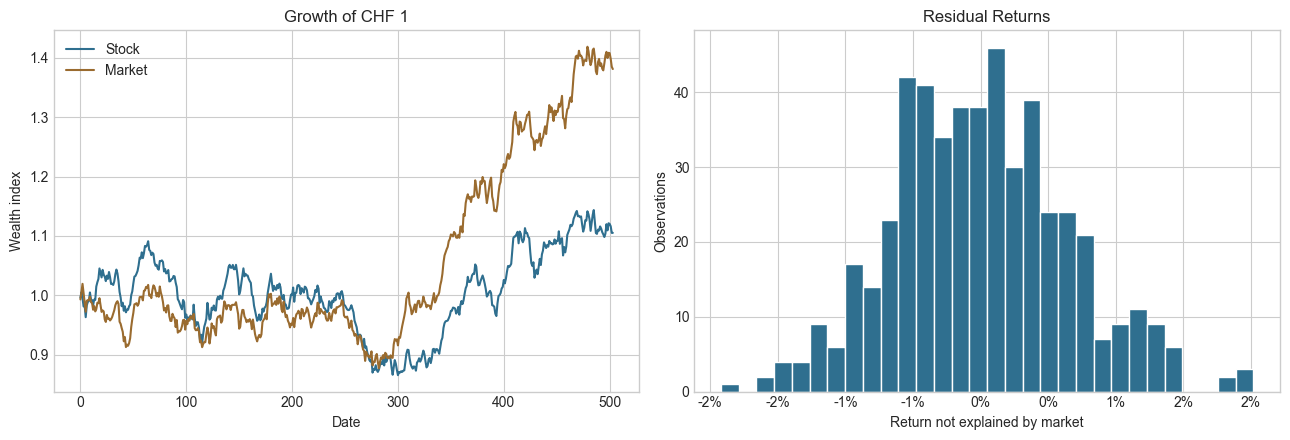

In [11]:
wealth = (1 + data[["stock_return", "market_return"]]).cumprod()
wealth.columns = ["Stock", "Market"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

wealth.plot(ax=axes[0], color=["#2f6f8f", "#9a6b2f"])
axes[0].set_title("Growth of CHF 1")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Wealth index")

axes[1].hist(data["residual_return"], bins=30, color="#2f6f8f", edgecolor="white")
axes[1].set_title("Residual Returns")
axes[1].set_xlabel("Return not explained by market")
axes[1].set_ylabel("Observations")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

plt.tight_layout()
plt.show()

## 5. Application

Alpha and beta estimates are used in several parts of financial research:

- **WACC and valuation**: beta feeds the CAPM cost of equity.
- **Risk management**: beta estimates market exposure and potential sensitivity in selloffs.
- **Portfolio construction**: beta helps decide whether a portfolio is defensive, neutral, or aggressive versus a benchmark.
- **Performance analysis**: alpha asks whether returns were better or worse than expected after controlling for market exposure.

For real company work, beta should be estimated with clean adjusted prices, a suitable benchmark, enough history, and a frequency that matches the use case. Daily beta can be noisy; monthly beta can be slow to react. Analysts often compare several windows and may adjust beta toward an industry or long-term average.

Delta and gamma answer a different question. They measure how an option's value changes when the underlying stock price changes. Alpha and beta explain realized stock or portfolio returns relative to a benchmark. So they are cousins in the broad idea of sensitivity, but they are not calculated from the same data.

In [12]:
interpretation = pd.DataFrame({
    "question": [
        "Is the stock defensive?",
        "Did the stock earn positive alpha?",
        "How much did the market model explain?",
        "How much active risk versus the benchmark?",
    ],
    "answer": [
        "Yes" if beta < 1 else "No",
        "Yes" if alpha_daily > 0 else "No",
        f"R-squared was {r_squared:.1%}",
        f"Tracking error was {tracking_error:.1%}",
    ],
})

interpretation

,question,answer
0,Is the stock defensive?,Yes
1,Did the stock earn positive alpha?,No
2,How much did the market model explain?,R-squared was 54.6%
3,How much active risk versus the benchmark?,Tracking error was 11.3%


## 6. Reflection

- Beta is calculated from returns, not from price levels.
- Alpha is the intercept of a return model, not proof of manager skill by itself.
- Beta depends on benchmark choice, time window, frequency, and market regime.
- Rolling beta can reveal instability that a single full-period estimate hides.
- Residual volatility is the stock-specific part left after the market model.

Questions to answer after running the notebook:

1. Why do we estimate beta from returns instead of prices?
2. What does beta below 1 imply for a defensive company?
3. Why might alpha disappear out of sample?
4. How would the estimate change if you used a different benchmark?